In [ ]:
# Training a GAN on the MNIST
from numpy import expand_dims
from numpy import zeros
from numpy import ones
from numpy import vstack
from numpy.random import randn
from numpy.random import randint
from keras.datasets.mnist import load_data
from tensorflow.keras.optimizers import Adam
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Reshape
from keras.layers import Flatten
from keras.layers import Conv2D
from keras.layers import Conv2DTranspose
from keras.layers import LeakyReLU
from keras.layers import Dropout
from matplotlib import pyplot as plt

#### End-to-end example: a GAN training loop from scratch
You may be familiar with Generative Adversarial Networks (GANs). GANs can generate new images that look almost real, by learning the latent distribution of a training dataset of images (the "latent space" of the images).

A GAN is made of two parts: a "generator" model that maps points in the latent space to points in image space, a "discriminator" model, a classifier that can tell the difference between real images (from the training dataset) and fake images (the output of the generator network).

A GAN training loop looks like this:

1) Train the discriminator. - Sample a batch of random points in the latent space. - Turn the points into fake images via the "generator" model. - Get a batch of real images and combine them with the generated images. - Train the "discriminator" model to classify generated vs. real images.

2) Train the generator. - Sample random points in the latent space. - Turn the points into fake images via the "generator" network. - Get a batch of real images and combine them with the generated images. - Train the "generator" model to "fool" the discriminator and classify the fake images as real.

For a much more detailed overview of how GANs works, see Deep Learning with Python.

**Sources:**
- https://www.tensorflow.org/guide/keras/writing_a_training_loop_from_scratch
- https://www.deeplearningbook.org/
- https://arxiv.org/abs/1406.2661
- https://arxiv.org/abs/1511.06434

In [2]:
# define the standalone discriminator model
def define_discriminator(in_shape=(28, 28, 1)):
    model = Sequential()
    # normal
    model.add(Conv2D(64, (3, 3), padding='same', input_shape=in_shape))
    model.add(LeakyReLU(alpha=0.2))
    # downsample to 14x14
    model.add(Conv2D(64, (3, 3), strides=(2, 2), padding='same'))
    model.add(LeakyReLU(alpha=0.2))
    # downsample to 7x7
    model.add(Conv2D(128, (3, 3), strides=(2, 2), padding='same'))
    model.add(LeakyReLU(alpha=0.2))
    # classifier
    model.add(Flatten())
    model.add(Dropout(0.4))
    model.add(Dense(1, activation='sigmoid'))
    # compile model
    opt = Adam(lr=0.0002, beta_1=0.5)
    model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])
    return model

In [3]:
# define the standalone generator model
def define_generator(latent_dim):
    model = Sequential()
    # foundation for 7x7 image
    n_nodes = 128 * 7 * 7
    model.add(Dense(n_nodes, input_dim=latent_dim))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Reshape((7, 7, 128)))
    # upsample to 14x14
    model.add(Conv2DTranspose(128, (4, 4), strides=(2, 2), padding='same'))
    model.add(LeakyReLU(alpha=0.2))
    # upsample to 28x28
    model.add(Conv2DTranspose(128, (4, 4), strides=(2, 2), padding='same'))
    model.add(LeakyReLU(alpha=0.2))
    # output layer
    model.add(Conv2D(1, (7, 7), activation='sigmoid', padding='same'))
    return model

In [4]:
# define the combined generator and discriminator model, for updating the generator
def define_gan(g_model, d_model):
    # make weights in the discriminator not trainable
    d_model.trainable = False
    # connect them
    model = Sequential()
    # add generator
    model.add(g_model)
    # add the discriminator
    model.add(d_model)
    # compile model
    opt = Adam(lr=0.0002, beta_1=0.5)
    model.compile(loss='binary_crossentropy', optimizer=opt)
    return model

In [6]:
gModel = define_generator(100)
dModel = define_discriminator()
model = define_gan(gModel, dModel)

print(model.summary())

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_3 (Sequential)   (None, 28, 28, 1)         1164289   
                                                                 
 sequential_4 (Sequential)   (None, 1)                 117697    
                                                                 
Total params: 1281986 (4.89 MB)
Trainable params: 1164289 (4.44 MB)
Non-trainable params: 117697 (459.75 KB)
_________________________________________________________________
None


In [7]:
# Load and prepare the MNIST dataset
def load_real_samples():
    # load the images
    (trainX, _), (_, _) = load_data()
    # expand to 3d, e.g. add channels dimension
    X = expand_dims(trainX, axis=-1)
    # convert from unsigned ints to floats
    X = X.astype('float32')
    # scale from [0,255] to [0,1]
    X = X / 255.0
    return X

# select real samples
def generate_real_samples(dataset, n_samples):
    # choose random instances
    ix = randint(0, dataset.shape[0], n_samples)
    # select images
    X = dataset[ix]
    # generate 'real' class labels (1)
    y = ones((n_samples, 1))
    return X, y

# generate points in latent space as input for the generator
def generate_latent_points(latent_dim, n_samples):
    # generate points in the latent space
    x_input = randn(latent_dim * n_samples)
    # reshape into a batch of inputs for the network
    x_input = x_input.reshape(n_samples, latent_dim)
    return x_input

# use the generator to generate n fake examples, with class labels
def generate_fake_samples(g_model, latent_dim, n_samples):
    # generate points in latent space
    x_input = generate_latent_points(latent_dim, n_samples)
    # predict outputs
    X = g_model.predict(x_input)
    # create 'fake' class labels (0)
    y = zeros((n_samples, 1))
    return X, y

# create and save a plot of generated images
def save_plot(examples, epoch, n=10):
    # scale from [0,1] to [0,255]
    examples = examples * 255.0
    examples = examples.astype('uint8')
    # plot images
    for i in range(n * n):
        plt.subplot(n, n, 1 + i)
        plt.axis('off')
        plt.imshow(examples[i, :, :, 0], cmap='gray_r')
    # save plot to file
    filename = 'generated_plot_e%03d.png' % (epoch + 1)
    plt.savefig(filename)
    plt.close()
    
# evaluate the discriminator, plot generated images, save model
def summarize_performance(epoch, g_model, d_model, dataset, latent_dim, n_samples=100):
    # prepare real samples
    X_real, y_real = generate_real_samples(dataset, n_samples)
    # evaluate discriminator on real examples
    _, acc_real = d_model.evaluate(X_real, y_real, verbose=0)
    # prepare fake examples
    x_fake, y_fake = generate_fake_samples(g_model, latent_dim, n_samples)
    # evaluate discriminator on fake examples
    _, acc_fake = d_model.evaluate(x_fake, y_fake, verbose=0)
    print('>Accuracy real: %.0f%%, fake: %.0f%%' % (acc_real * 100, acc_fake * 100))
    # save plot
    save_plot(x_fake, epoch)
    # save the generator model tile file
    filename = 'generator_model_%03d.h5' % (epoch + 1)
    g_model.save(filename)

In [9]:
# train the generator and discriminator
def train(g_model, d_model, gan_model, dataset, latent_dim, n_epochs=15, n_batch=256):
    bat_per_epo = int(dataset.shape[0] / n_batch)
    half_batch = int(n_batch / 2)
    # manually enumerate epochs
    for i in range(n_epochs):
        # enumerate batches over the training set
        for j in range(bat_per_epo):
            # get randomly selected 'real' samples
            X_real, y_real = generate_real_samples(dataset, half_batch)
            # update discriminator model weights
            d_loss1, _ = d_model.train_on_batch(X_real, y_real)
            # generate 'fake' examples
            X_fake, y_fake = generate_fake_samples(g_model, latent_dim, half_batch)
            # update discriminator model weights
            d_loss2, _ = d_model.train_on_batch(X_fake, y_fake)
            # prepare points in latent space as input for the generator
            x_gan = generate_latent_points(latent_dim, n_batch)
            # create inverted labels for the fake samples
            y_gan = ones((n_batch, 1))
            # update the generator via the discriminator's error
            g_loss = gan_model.train_on_batch(x_gan, y_gan)
            # summarize loss on this batch
            print('>%d, %d/%d, d1=%.3f, d2=%.3f g=%.3f' %
                (i + 1, j + 1, bat_per_epo, d_loss1, d_loss2, g_loss))
        # evaluate the model performance every epoch
        summarize_performance(i, g_model, d_model, dataset, latent_dim)
        
# size of the latent space
latent_dim = 100
# create the discriminator
dModel = define_discriminator()
# create the generator
gModel = define_generator(latent_dim)
# create the gan
ganModel = define_gan(gModel, dModel)
# load image data
dataset = load_real_samples()
print('Dataset Loaded')
# train model
train(gModel, dModel, ganModel, dataset, latent_dim)

Dataset Loaded
4/4 [==============================] - 0s 7ms/step
>1, 1/234, d1=0.696, d2=0.759 g=0.715
4/4 [==============================] - 0s 6ms/step
>1, 2/234, d1=0.656, d2=0.656 g=0.826
4/4 [==============================] - 0s 6ms/step
>1, 3/234, d1=0.640, d2=0.557 g=1.059
4/4 [==============================] - 0s 6ms/step
>1, 4/234, d1=0.607, d2=0.450 g=1.344
4/4 [==============================] - 0s 6ms/step
>1, 5/234, d1=0.496, d2=0.507 g=1.145
4/4 [==============================] - 0s 6ms/step
>1, 6/234, d1=0.280, d2=0.882 g=0.741
4/4 [==============================] - 0s 6ms/step
>1, 7/234, d1=0.116, d2=0.736 g=0.756
4/4 [==============================] - 0s 6ms/step
>1, 8/234, d1=0.056, d2=0.632 g=0.837
4/4 [==============================] - 0s 6ms/step
>1, 9/234, d1=0.036, d2=0.550 g=1.022
4/4 [==============================] - 0s 6ms/step
>1, 10/234, d1=0.024, d2=0.402 g=1.470
4/4 [==============================] - 0s 6ms/step
>1, 11/234, d1=0.053, d2=0.238 g=2.162
4/4 

4/4 [==============================] - 0s 6ms/step
>2, 1/234, d1=0.000, d2=0.000 g=10.727
4/4 [==============================] - 0s 6ms/step
>2, 2/234, d1=0.000, d2=0.000 g=10.799
4/4 [==============================] - 0s 6ms/step
>2, 3/234, d1=0.000, d2=0.000 g=10.763
4/4 [==============================] - 0s 6ms/step
>2, 4/234, d1=0.000, d2=0.000 g=10.810
4/4 [==============================] - 0s 6ms/step
>2, 5/234, d1=0.000, d2=0.000 g=10.748
4/4 [==============================] - 0s 6ms/step
>2, 6/234, d1=0.000, d2=0.000 g=10.697
4/4 [==============================] - 0s 6ms/step
>2, 7/234, d1=0.000, d2=0.000 g=10.920
4/4 [==============================] - 0s 6ms/step
>2, 8/234, d1=0.000, d2=0.000 g=10.846
4/4 [==============================] - 0s 6ms/step
>2, 9/234, d1=0.000, d2=0.000 g=10.982
4/4 [==============================] - 0s 6ms/step
>2, 10/234, d1=0.000, d2=0.000 g=10.853
4/4 [==============================] - 0s 6ms/step
>2, 11/234, d1=0.000, d2=0.000 g=10.859
4/4 [===

4/4 [==============================] - 0s 6ms/step
>3, 1/234, d1=0.000, d2=0.000 g=12.357
4/4 [==============================] - 0s 6ms/step
>3, 2/234, d1=0.000, d2=0.000 g=12.355
4/4 [==============================] - 0s 6ms/step
>3, 3/234, d1=0.000, d2=0.000 g=12.332
4/4 [==============================] - 0s 6ms/step
>3, 4/234, d1=0.000, d2=0.000 g=12.351
4/4 [==============================] - 0s 6ms/step
>3, 5/234, d1=0.000, d2=0.000 g=12.377
4/4 [==============================] - 0s 6ms/step
>3, 6/234, d1=0.000, d2=0.000 g=12.491
4/4 [==============================] - 0s 6ms/step
>3, 7/234, d1=0.000, d2=0.000 g=12.263
4/4 [==============================] - 0s 6ms/step
>3, 8/234, d1=0.000, d2=0.000 g=12.367
4/4 [==============================] - 0s 6ms/step
>3, 9/234, d1=0.000, d2=0.000 g=12.415
4/4 [==============================] - 0s 6ms/step
>3, 10/234, d1=0.000, d2=0.000 g=12.459
4/4 [==============================] - 0s 6ms/step
>3, 11/234, d1=0.000, d2=0.000 g=12.309
4/4 [===

4/4 [==============================] - 0s 6ms/step
>4, 1/234, d1=0.000, d2=0.000 g=21.914
4/4 [==============================] - 0s 6ms/step
>4, 2/234, d1=0.000, d2=0.000 g=21.772
4/4 [==============================] - 0s 6ms/step
>4, 3/234, d1=0.000, d2=0.000 g=21.874
4/4 [==============================] - 0s 6ms/step
>4, 4/234, d1=0.000, d2=0.000 g=21.800
4/4 [==============================] - 0s 6ms/step
>4, 5/234, d1=0.000, d2=0.000 g=21.702
4/4 [==============================] - 0s 6ms/step
>4, 6/234, d1=0.000, d2=0.000 g=21.761
4/4 [==============================] - 0s 6ms/step
>4, 7/234, d1=0.000, d2=0.000 g=21.698
4/4 [==============================] - 0s 6ms/step
>4, 8/234, d1=0.000, d2=0.000 g=21.732
4/4 [==============================] - 0s 6ms/step
>4, 9/234, d1=0.000, d2=0.000 g=21.756
4/4 [==============================] - 0s 6ms/step
>4, 10/234, d1=0.000, d2=0.000 g=21.878
4/4 [==============================] - 0s 6ms/step
>4, 11/234, d1=0.000, d2=0.000 g=21.821
4/4 [===

4/4 [==============================] - 0s 6ms/step
>5, 1/234, d1=0.000, d2=0.000 g=21.895
4/4 [==============================] - 0s 6ms/step
>5, 2/234, d1=0.000, d2=0.000 g=21.820
4/4 [==============================] - 0s 6ms/step
>5, 3/234, d1=0.000, d2=0.000 g=21.990
4/4 [==============================] - 0s 6ms/step
>5, 4/234, d1=0.000, d2=0.000 g=21.760
4/4 [==============================] - 0s 6ms/step
>5, 5/234, d1=0.000, d2=0.000 g=21.852
4/4 [==============================] - 0s 6ms/step
>5, 6/234, d1=0.000, d2=0.000 g=21.774
4/4 [==============================] - 0s 6ms/step
>5, 7/234, d1=0.000, d2=0.000 g=22.037
4/4 [==============================] - 0s 6ms/step
>5, 8/234, d1=0.000, d2=0.000 g=21.670
4/4 [==============================] - 0s 6ms/step
>5, 9/234, d1=0.000, d2=0.000 g=21.791
4/4 [==============================] - 0s 6ms/step
>5, 10/234, d1=0.000, d2=0.000 g=21.609
4/4 [==============================] - 0s 6ms/step
>5, 11/234, d1=0.000, d2=0.000 g=21.876
4/4 [===

...

4/4 [==============================] - 0s 6ms/step
>11, 1/234, d1=0.000, d2=0.000 g=21.824
4/4 [==============================] - 0s 6ms/step
>11, 2/234, d1=0.000, d2=0.000 g=21.756
4/4 [==============================] - 0s 6ms/step
>11, 3/234, d1=0.000, d2=0.000 g=21.772
4/4 [==============================] - 0s 6ms/step
>11, 4/234, d1=0.000, d2=0.000 g=21.912
4/4 [==============================] - 0s 6ms/step
>11, 5/234, d1=0.000, d2=0.000 g=21.794
4/4 [==============================] - 0s 6ms/step
>11, 6/234, d1=0.000, d2=0.000 g=21.824
4/4 [==============================] - 0s 6ms/step
>11, 7/234, d1=0.000, d2=0.000 g=21.834
4/4 [==============================] - 0s 6ms/step
>11, 8/234, d1=0.000, d2=0.000 g=21.930
4/4 [==============================] - 0s 6ms/step
>11, 9/234, d1=0.000, d2=0.000 g=21.906
4/4 [==============================] - 0s 6ms/step
>11, 10/234, d1=0.000, d2=0.000 g=21.961
4/4 [==============================] - 0s 6ms/step
>11, 11/234, d1=0.000, d2=0.000 g=21.6

4/4 [==============================] - 0s 6ms/step
>12, 1/234, d1=0.000, d2=0.000 g=21.809
4/4 [==============================] - 0s 6ms/step
>12, 2/234, d1=0.000, d2=0.000 g=21.708
4/4 [==============================] - 0s 6ms/step
>12, 3/234, d1=0.000, d2=0.000 g=21.979
4/4 [==============================] - 0s 6ms/step
>12, 4/234, d1=0.000, d2=0.000 g=21.819
4/4 [==============================] - 0s 6ms/step
>12, 5/234, d1=0.000, d2=0.000 g=21.888
4/4 [==============================] - 0s 6ms/step
>12, 6/234, d1=0.000, d2=0.000 g=21.977
4/4 [==============================] - 0s 6ms/step
>12, 7/234, d1=0.000, d2=0.000 g=21.754
4/4 [==============================] - 0s 6ms/step
>12, 8/234, d1=0.000, d2=0.000 g=21.879
4/4 [==============================] - 0s 6ms/step
>12, 9/234, d1=0.000, d2=0.000 g=21.845
4/4 [==============================] - 0s 6ms/step
>12, 10/234, d1=0.000, d2=0.000 g=21.892
4/4 [==============================] - 0s 6ms/step
>12, 11/234, d1=0.000, d2=0.000 g=21.8

4/4 [==============================] - 0s 6ms/step
>13, 1/234, d1=0.000, d2=0.000 g=21.763
4/4 [==============================] - 0s 6ms/step
>13, 2/234, d1=0.000, d2=0.000 g=21.778
4/4 [==============================] - 0s 6ms/step
>13, 3/234, d1=0.000, d2=0.000 g=21.965
4/4 [==============================] - 0s 6ms/step
>13, 4/234, d1=0.000, d2=0.000 g=21.822
4/4 [==============================] - 0s 7ms/step
>13, 5/234, d1=0.000, d2=0.000 g=21.781
4/4 [==============================] - 0s 6ms/step
>13, 6/234, d1=0.000, d2=0.000 g=21.685
4/4 [==============================] - 0s 6ms/step
>13, 7/234, d1=0.000, d2=0.000 g=21.908
4/4 [==============================] - 0s 6ms/step
>13, 8/234, d1=0.000, d2=0.000 g=21.917
4/4 [==============================] - 0s 6ms/step
>13, 9/234, d1=0.000, d2=0.000 g=21.905
4/4 [==============================] - 0s 6ms/step
>13, 10/234, d1=0.000, d2=0.000 g=21.857
4/4 [==============================] - 0s 6ms/step
>13, 11/234, d1=0.000, d2=0.000 g=21.9

4/4 [==============================] - 0s 6ms/step
>14, 1/234, d1=0.000, d2=0.000 g=21.882
4/4 [==============================] - 0s 6ms/step
>14, 2/234, d1=0.000, d2=0.000 g=21.791
4/4 [==============================] - 0s 6ms/step
>14, 3/234, d1=0.000, d2=0.000 g=21.896
4/4 [==============================] - 0s 6ms/step
>14, 4/234, d1=0.000, d2=0.000 g=21.960
4/4 [==============================] - 0s 6ms/step
>14, 5/234, d1=0.000, d2=0.000 g=21.773
4/4 [==============================] - 0s 6ms/step
>14, 6/234, d1=0.000, d2=0.000 g=21.801
4/4 [==============================] - 0s 6ms/step
>14, 7/234, d1=0.000, d2=0.000 g=21.782
4/4 [==============================] - 0s 6ms/step
>14, 8/234, d1=0.000, d2=0.000 g=21.813
4/4 [==============================] - 0s 6ms/step
>14, 9/234, d1=0.000, d2=0.000 g=22.009
4/4 [==============================] - 0s 6ms/step
>14, 10/234, d1=0.000, d2=0.000 g=21.945
4/4 [==============================] - 0s 6ms/step
>14, 11/234, d1=0.000, d2=0.000 g=22.0

4/4 [==============================] - 0s 6ms/step
>15, 1/234, d1=0.000, d2=0.000 g=21.972
4/4 [==============================] - 0s 7ms/step
>15, 2/234, d1=0.000, d2=0.000 g=21.999
4/4 [==============================] - 0s 6ms/step
>15, 3/234, d1=0.000, d2=0.000 g=21.930
4/4 [==============================] - 0s 6ms/step
>15, 4/234, d1=0.000, d2=0.000 g=21.957
4/4 [==============================] - 0s 7ms/step
>15, 5/234, d1=0.000, d2=0.000 g=21.848
4/4 [==============================] - 0s 6ms/step
>15, 6/234, d1=0.000, d2=0.000 g=21.847
4/4 [==============================] - 0s 6ms/step
>15, 7/234, d1=0.000, d2=0.000 g=21.926
4/4 [==============================] - 0s 6ms/step
>15, 8/234, d1=0.000, d2=0.000 g=21.847
4/4 [==============================] - 0s 6ms/step
>15, 9/234, d1=0.000, d2=0.000 g=21.819
4/4 [==============================] - 0s 6ms/step
>15, 10/234, d1=0.000, d2=0.000 g=21.767
4/4 [==============================] - 0s 6ms/step
>15, 11/234, d1=0.000, d2=0.000 g=21.8

4/4 [==============================] - 0s 7ms/step


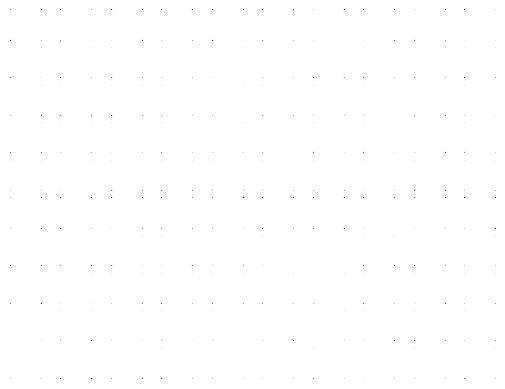

In [10]:
# example of loading the generator model and generating images
from keras.models import load_model
from numpy.random import randn
from matplotlib import pyplot as plt

# generate points in latent space as input for the generator
def generate_latent_points(latent_dim, n_samples):
    # generate points in the latent space
    x_input = randn(latent_dim * n_samples)
    # reshape into a batch of inputs for the network
    x_input = x_input.reshape(n_samples, latent_dim)
    return x_input

# create and save a plot of generated images
def save_plot(examples, n):
    # plot images
    for i in range(n * n):
        plt.subplot(n, n, 1 + i)
        plt.axis('off')
        plt.imshow(examples[i, :, :, 0], cmap='gray_r')
    plt.show()

# load model
model = load_model('generator_model_015.h5')
# generate images
latent_points = generate_latent_points(100, 100)
X = model.predict(latent_points)
# plot the result
save_plot(X, 10)